In [1]:
import cv2
import os
import glob
from pathlib import Path
import skimage as ski
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
# IDENTIFYING FOLDER
parent_folder_str = "C:..." # Location of the parent folder containing the subfolders with videos
parent_folder = Path(r"C:...")
dirs_list = os.listdir(parent_folder)

# list of the subfolders generated by PFV software
vid_folder_list = []
for f in dirs_list:
    p = parent_folder_str + "\\" + f
    p = Path(p)
    vid_folder_list.append(p)

fold_names = [f.name for f in vid_folder_list]  # List of folder names

# list of files  
filelst = []
for f in vid_folder_list[7:8]:
    for v in f.glob("*mp4"):    # For all files rather than just the first
        filelst.append(v)

# filelst = [filelst[0], filelst[4], filelst[6]]
# list of the filenames
filenames = [f.name for f in filelst]

# TEST: Printing first file name
# print(len(filelst))
# print(filenames[0])
filenames

['GP Run 6_2percentHA_20250923_104339.mp4']

In [423]:
# FUNCTIONS: 
# Functions will operate on a single image (i.e.  a frame), so will need to use these functions in a for loop to iterate through the video.

# Image processing for getting the top and bottom plate heights. 

def plate_h_crop_img():
    ...

def plate_h_cropped_grayscale(frame: np.ndarray) -> np.ndarray:
    """ Takes a raw frame of the video in BGR format (for cv2), and converts it to a grayscale format compatible for use with scikit image.
    Useful for rendering quickly viewing the image 
    frame = raw frame
    returns: cropped frame in grayscale"""
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)      # Convert from BGR to RGB
    grayscale = ski.color.rgb2gray(rgb_frame)               # Convert to grayscale
    # cropped = plate_h_crop_img(frame)
    cropped = grayscale[400:900, 125:425]                   # Cropping default:  grayscale[300:900, 160:310]  
    return cropped

def plate_h_enhhance_contrast(frame: np.ndarray) -> np.ndarray:
    """ Takes a raw frame of the video and returns a cropped, blurred and sigmoid-corrected grayscale image"""
    cropped = plate_h_cropped_grayscale(frame)
    blurred = ski.filters.gaussian(cropped, sigma = 0.5)    # Gaussian blur
    contrast_enhanced_img = ski.exposure.adjust_sigmoid(blurred, cutoff = 0.35, gain = 15)
    return contrast_enhanced_img

def plate_h_edge_binarize(frame: np.ndarray, sobel_mask_val: float = 0.6, morph_star_kernel_size: int = 10) -> np.ndarray:
    """ Takes a contrast enhanced frame and binarizes after finding edges via the sobel filter. Returns the skeletonized image
    frame: the sigmoid corrected contrast enhanced frame
    sobel_mask_val: the value used to define the mask cutoff between the max and mean intensities. Default is 0.6"""
    sobeledge = ski.filters.sobel(frame)
    smask = sobeledge < (sobeledge.max() - sobeledge.mean())*sobel_mask_val
    sobeledge[smask] = 1
    sobeledge = ski.util.invert(sobeledge)                  # Sobel find edges and invert

    tvalue = ski.filters.threshold_otsu(sobeledge)          # otsu thresholding
    sobeledge = sobeledge > tvalue

    k = ski.morphology.star(morph_star_kernel_size)         # morphology corrections
    morph = ski.morphology.binary_closing(sobeledge, footprint = k)
    skeletonized = ski.morphology.skeletonize(morph)        # Skeletonizing
    return skeletonized

# Getting coordinates of top and bottom plates
def plate_h_get_hough_lines(frame: np.ndarray, hline_threshold: int = 10, hline_line_length: int = 20, hline_rng: int = 100, hline_line_gap: int = 15, top_cutoff: int = 400, bottom_cutoff: int = 450) -> tuple:
    """ Takes a skeletonized frame and finds the hough lines. 
    Returns a tuple of lists (top_lines, bottom_lines). Each line has format ((x0, y0), (x1, y1)), indicating line start and end"""
    theta = np.linspace(-np.pi/18, np.pi/18, 20)            # setting theta to be all vertical lines
    hough_lines = ski.transform.probabilistic_hough_line(frame, threshold = hline_threshold, line_length = hline_line_length, line_gap = hline_line_gap, theta = theta, rng = hline_rng)

    top_lines = []  
    bottom_lines = []
    h,w = frame.shape    
    for line in hough_lines:
        p0, p1 = line
        x0, y0 = p0
        x1, y1 = p1
        if x0 < w/3 or x0 > w*0.66:
            if x1 <w/3 or x1 > w*0.66:
                if y0 < top_cutoff and y1 < top_cutoff:
                    top_lines.append(line)
                elif y0 > bottom_cutoff and y1 > bottom_cutoff:
                    bottom_lines.append(line)
    return top_lines, bottom_lines

def get_top_plate_coords(top_lines):
    x_vals = []
    y_vals = []
    for line in top_lines:
        p0, p1 = line
        x0, y0 = p0
        x_vals.append(x0)
        y_vals.append(y0)
        x1, y1 = p1
        x_vals.append(x1)
        y_vals.append(y1)

    x_vals.sort()
    y_vals.sort()

    plate_coords = ((x_vals[0], y_vals[-1]), (x_vals[-1], y_vals[-1]))
    return plate_coords

def get_bottom_plate_coords(bottom_lines):
    x_vals_b = []
    y_vals_b = []
    for line in bottom_lines:
        p0, p1 = line
        x0, y0 = p0
        x_vals_b.append(x0)
        y_vals_b.append(y0)
        x1, y1 = p1
        x_vals_b.append(x1)
        y_vals_b.append(y1)

    x_vals_b.sort()
    y_vals_b.sort()

    plate_coords_bottom = ((x_vals_b[0], y_vals_b[0]), (x_vals_b[-1], y_vals_b[0]))
    return plate_coords_bottom

# just the y value to check if the height has been reached
def get_top_plate_height_y_coord(frame, sobel_mask_val: float = 0.6, morph_star_kernel_size: int = 10, hline_threshold: int = 10, hline_line_length: int = 20, hline_rng: int = 100, hline_line_gap: int = 15, mid_cuttoff: int = 450, top_cutoff: int = 400, bottom_cutoff: int = 450):
    contrast_enhanced = plate_h_enhhance_contrast(frame)
    edges = plate_h_edge_binarize(contrast_enhanced)
    top_lines, bottom_lines = plate_h_get_hough_lines(edges, top_cutoff=top_cutoff, bottom_cutoff=bottom_cutoff)
    p0, p1 = get_top_plate_coords(top_lines)
    return p0[1]

def end_height_reached(test_height, end_height, threshold: int = 5) -> bool:
    return test_height <= end_height + threshold


In [11]:
# FUNCTIONS: image analysis to get the widths - splitting the contours because when it gets too thin, the contours aren't split into left and right

# Image processing:

# Cropping happens with plate_h_cropped_grayscale(frame)

def caber_find_edges(frame: np.ndarray, gauss_sigma: float = 0.5, gamma: float = 5, morph_disk_kernel_size: int = 13) -> np.ndarray:
    cropped = plate_h_cropped_grayscale(frame)
    blurred = ski.filters.gaussian(cropped, sigma = gauss_sigma)
    gammacorr = ski.exposure.adjust_gamma(blurred, gamma = gamma, gain = 1)
    otsuv = ski.filters.threshold_otsu(gammacorr)
    gammacorr = gammacorr > otsuv
    k = ski.morphology.disk(morph_disk_kernel_size)
    morph = ski.morphology.binary_opening(gammacorr, footprint = k)
    return morph



def caber_find_contours(frame: np.ndarray, top_plate_y, bottom_plate_y:int = 450, min_contour_l: int = 300) -> np.ndarray:
    """Takes a morphology corrected and binarized image of the thinning process. 
    First, finds the contours, then filters contours to make sure there are only two contours arranged in ascending y value order.
    Returns a tuple of the two contours each an array of [row nums, col nums], where rows = y values and columns = x values of the image that make up the contours"""
    h,w = frame.shape
    contours = ski.measure.find_contours(frame)
    # Sometimes we get more than 2 contours. We only want to keep the two longest contours    
    if len(contours) > 2:
        contours_fil = [c for c in contours if len(c) > min_contour_l]
    else:
        contours_fil = contours      # check if number of contours > 2. If so, discard 
    if len(contours_fil) > 2:
        print(f"ERROR: there are more than 2 contours. Contours number = {len(contours_fil)}")
    else:
        y_fil_contours = []
        for c in contours_fil:
            mask = np.logical_and(top_plate_y < c[:,0], c[:,0] < bottom_plate_y)
            filc = c[mask]
            if filc[0][0] > filc[-1][0]:        # automatically appends such that first element has lowest y value
                y_fil_contours.append(filc[::-1])
            else:
                y_fil_contours.append(filc) 

    # making both contours have the same y values:
    a = []
    b = []
    for yx in y_fil_contours[0][:]:
        mask = y_fil_contours[1][:,0] == yx[0]  # finding the coordinates that have shared y values
        yx_b = y_fil_contours[1][mask]
        if len(yx_b) > 0:
            a.append(yx)        # add that coordinate to contour list a
            b.append(yx_b[0])   # add the matching coordinate to contour list b
            
    return a,b


def compute_thinning_distance(contour_a, contour_b) -> list:
    """ returns a list of [y value of break point, minimum distance]"""
    if len(contour_a) == 0 or len(contour_b) == 0:
        min_distance = 0
        break_point = np.nan
    else:
        distances = [] # each element in list is [y coordinate, x-distance]
        for i in range(len(contour_a)):
            d = abs(contour_a[i][1] - contour_b[i][1])
            distances.append([contour_a[i][0], d])
        distances = np.array(distances)
        min_distance = np.min(distances)            # finding the lowest distance
        # finding all y-values with that lowest distance
        mask = distances[:,1] == np.min(distances)
        min_pts = distances[mask]
        # Assuming the middle point is the one that is the mid_point
        if len(min_pts) > 1:
            break_point = min_pts[int((len(min_pts)/2))][0]
        else:
            break_point = min_pts[0][0]
    return [break_point, min_distance]


def get_t(frame_ind: int, n: int, t_col: int) -> float:
    """ Calculates the time point for each frame analyzed in processing pipeline.
    frame_ind = frame index from list of frames. 0th index will be t = 0 
    n = interval between frames that was saved into the list of frames. (Globally defined)
    t_col = frame rate in frames per second
    returns: time t in ms
    """
    t_per_frame = n * (1/t_col)*1000
    t = t_per_frame * frame_ind
    return t

In [ ]:
# Create the dataframe to store the y values of the top plate for each video file. Each column will be a different video file.
y_position_df = pd.DataFrame()

In [ ]:
## EXTRACT VIDEO FRAMES

# FILE
# Open video - cv2
file_num = 0
print(filenames[file_num])
col_rate = 1000   # in fps, actual collection rate

# 2. EXTRACTING FRAMES - USING DURATION OF EXPERIMENT TO DECIDE STARTING FRAME

# open video
cap = cv2.VideoCapture(filelst[file_num])
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Check if video was successfully opened:
if not cap.isOpened():
    print("Error: Could not open video file.")
else:
    print("Video file opened successfully!")

#set starting frame:
start_frame = 0 # 0 is start of exeperiment, can select a higher number if want to start later in the video (based on the duration of experiment)
cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
imgs = []                                   # list of np.ndarrays to store frames
n = 1                                     # every nth frame to keep. Change to 1 if want all frames
fr_num = start_frame

while True:
    ret, frame = cap.read()
    if ret:
        if fr_num % n == 0:
            imgs.append(frame)
        fr_num +=1
    else:
        print(f"did not open frame {fr_num}")
        print(f"saved {len(imgs)} frames out of {fr_num} frames")
        break
    
cap.release()

# outputs
print(start_frame)

In [ ]:
y_vals = [] #position
x_vals = [] #time
for i, img in enumerate(imgs[0:700]): # select frames to analyze (should span the lifting process.)
    contrast_enhanced = plate_h_enhhance_contrast(img) # process image
    binarized = plate_h_edge_binarize(contrast_enhanced) # binarize image

    # get the top and bottom plate coordinates for each frame
    top_lines, bottom_lines = plate_h_get_hough_lines(binarized,
                                                    hline_threshold = 10, 
                                                    hline_line_length = 20, 
                                                    hline_rng = 100, 
                                                    hline_line_gap = 15, 
                                                    top_cutoff = 280, bottom_cutoff = 320)
    top_plate_coords = get_top_plate_coords(top_lines)
    bottom_plate_coords = get_bottom_plate_coords(bottom_lines)

    # Save the y and x values for each frame
    y_vals.append(top_plate_coords[0][1])
    x_vals.append(i)


Text(0, 0.5, 'End plate y location')

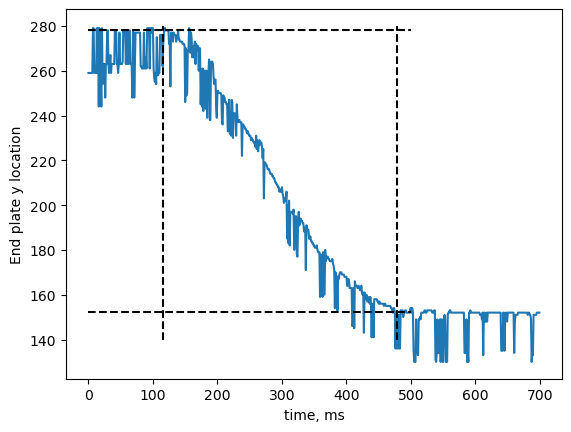

In [ ]:
# plot and manually find starting and ending points of lifting process
plt.plot(x_vals[:], y_vals[:]) # Plot x and y values

# Manually draw lines to see points of intersection
plt.plot((0,500), (152.5,152.5), color = "black", linestyle = "--")
plt.plot((478,478), (140,280), color = "black", linestyle = "--")

plt.plot((0,500), (278,278), color = "black", linestyle = "--")
plt.plot((115,115), (140,280), color = "black", linestyle = "--")


plt.xlabel("time, ms")
plt.ylabel("End plate y location")

In [ ]:
# based on the the plot, select x and y value ranges for lifting process and save to data frame
y_position_df[f"time, ms_{file_num}"]= x_vals[0:450] 
y_position_df[f"top_plate_y, px_{file_num}"] = y_vals[0:450]

In [ ]:
## MAKE SURE THIS IS DONE FOR EVERY VIDEO IN YOU WANT TO ANALYZE
# Saving raw data to csv
y_position_df.to_csv(f"{parent_folder}/00_processed/water_plate_positioning.csv", index = False)

In [ ]:
# Plotting y position of top plate over time for all videos
# make sure to change x, y ranges based on what area you want to see. For the figure, we plotted the entire lifting process

from scipy.stats import linregress

font = {'family': 'Arial',
        'color':  'black',
        'weight': 'normal',
        'size': 16,
        }
cmap = plt.cm.Greens
for i in range(int(y_position_df.shape[1]/2)):
    mask = y_position_df[f"top_plate_y, px_{i}"] < y_position_df[f"top_plate_y, px_{i}"][0]
    x = y_position_df[f"time, ms_{i}"][:][mask]/4
    y_raw = y_position_df[f"top_plate_y, px_{i}"][:][mask]
    y = (((y_raw - y_position_df[f"top_plate_y, px_{i}"][0:200][mask].mean()).abs()*0.046)).rolling(window=10).mean()
    plt.plot(x, y, label = i, marker = "o", markersize = 1, linestyle = "", color = cmap(i/12+0.2))

plt.ylim(-0.1,5.5)
plt.xlim(37,150)
plt.tick_params(axis = "both", which = "both", direction = "in", top = "true", right = "true")
plt.xlabel("Time, ms", fontsize = 12, fontdict= font)
plt.ylabel("End plate z position, mm", fontsize = 12, fontdict= font)
# plt.savefig(f"{parent_folder}/00_processed/water_plate_positioning.png", dpi = 300, transparent = True)


In [ ]:
# Plotting y position of top plate over time for all videos - if you want to go one at a time

from scipy.stats import linregress

font = {'family': 'Arial',
        'color':  'black',
        'weight': 'normal',
        'size': 16,
        }
cmap = plt.cm.Greens
i = 0
x = y_position_df[f"time, ms_{i}"][:]/4+3.5
y_raw = y_position_df[f"top_plate_y, px_{i}"][:]
y = ((y_raw).abs()*0.041).rolling(window=21).mean()
plt.plot(x, y, label = i, marker = "o", markersize = 1, linestyle = "", color = cmap(i/3+0.2))



i = 1
x = y_position_df[f"time, ms_{i}"][:]/4
y_raw = y_position_df[f"top_plate_y, px_{i}"][:]
y = ((y_raw).abs()*0.041).rolling(window=21).mean()
plt.plot(x, y, label = i, marker = "o", markersize = 1, linestyle = "", color = cmap(i/3+0.2))


i = 2
x = y_position_df[f"time, ms_{i}"][:]/4 + 14
y_raw = y_position_df[f"top_plate_y, px_{i}"][:]
y = ((y_raw).abs()*0.041).rolling(window=21).mean()
plt.plot(x, y, label = i, marker = "o", markersize = 1, linestyle = "", color = cmap(i/3+0.2))
plt.plot((0,140), (6.2,6.2), color = "black", linestyle = "--")
plt.plot((0,140), (11.2,11.2), color = "black", linestyle = "--")

    # slope, intercept, r_value, p_value, std_err = linregress(x.values[25*4:95*4], y.values[25*4:95*4])
    # print(slope)
    # plt.plot(x.values[25*4:95*4], slope*(x.values[25*4:95*4]) + intercept, color = "black", linestyle = "--")

# plt.ylim(-0.1,5.5)
plt.xlim(100,130)
plt.tick_params(axis = "both", which = "both", direction = "in", top = "true", right = "true")
plt.xlabel("Time, ms", fontsize = 12, fontdict= font)
plt.ylabel("End plate z position, mm", fontsize = 12, fontdict= font)
plt.legend()
# plt.savefig(f"{parent_folder}/00_processed/water_plate_positioning.png", dpi = 300, transparent = True)


np.float64(0.09139030118331624)

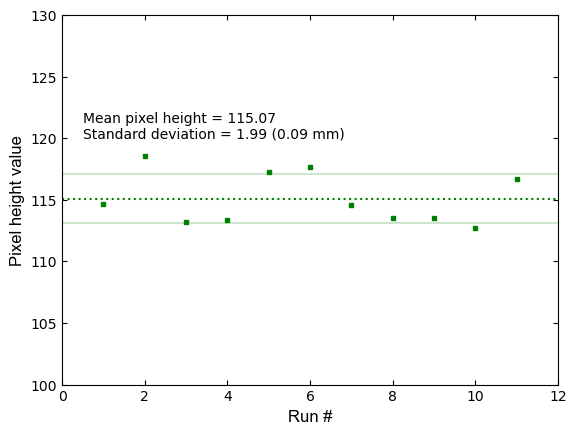

In [ ]:
## PLOTTING THE DISTANCE TRAVELLED BY THE TOP PLATE IN EACH EXPERIMENT - figure 2b aeris

y_position_df

avg_ys = []
for i in range(int(y_position_df.shape[1]/2)): # i = the video number; got from total number of experiments
    y = y_position_df[f"top_plate_y, px_{i}"][400:500].rolling(window=15).mean() # plateau region at start of experiment
    y_start = y_position_df[f"top_plate_y, px_{i}"][0:200].rolling(window=15).mean()  # plateau region at end of experiment
    y_final = abs(y.mean() - y_start.mean()) # distance travelled by the top plate in pixels
    avg_ys.append(y_final) # Append the distance to the list of distances.

np.mean(avg_ys)
# Mean distance travelled = 5.29353860589672 +/- 0.09 mm

x = range(1, int(y_position_df.shape[1]/2 +1))
plt.plot(x, avg_ys, marker = "s", markersize = 3, linestyle = "", color = "green")
plt.plot((0,12), (np.mean(avg_ys), np.mean(avg_ys)), linestyle = ":", color = "green" )
plt.plot((0,12), (np.mean(avg_ys)+np.std(avg_ys), np.mean(avg_ys)+np.std(avg_ys)), linestyle = "-", color = "green", alpha = 0.2 )
plt.plot((0,12), (np.mean(avg_ys)-np.std(avg_ys), np.mean(avg_ys)-np.std(avg_ys)), linestyle = "-", color = "green", alpha = 0.2 )
plt.ylim(100,130)
plt.xlim(0,12)
plt.xlabel("Run #", fontsize = 12, fontdict= font)
plt.ylabel("Pixel height value", fontsize = 12, fontdict= font)
plt.tick_params(axis = "both", which = "both", direction = "in", top = "true", right = "true")
plt.text(0.5, 120, f"Mean pixel height = {np.mean(avg_ys):.2f}\nStandard deviation = {np.std(avg_ys):.2f} ({np.std(avg_ys)*0.046:.2f} mm)")
# plt.savefig(f"{parent_folder}/00_processed/end_plate_positioning.png", dpi = 300, transparent = True)

np.std(avg_ys)*0.046 # To conver to mm, multiply by 0.046. This is the pixel to mm conversion factor for the videos.
